# Image Captioning with Vision-Language Models
### Fine-Tuning BLIP on Flickr8k

This experiment compares a pretrained BLIP checkpoint with the same model after fine-tuning on Flickr8k. The visual encoder is frozen, and the text decoder is updated using image-caption pairs. Captions are generated in English.

The model is selected using validation loss and evaluated on the held-out test split. Evaluation includes BLEU, CIDEr, generation time, GPU memory use, and a manual review of generated captions.


## 1. Environment

Run this notebook in Google Colab with a GPU runtime. The installation below pins the main dependencies and uses the PyTorch installation provided by Colab. If these libraries have already been imported, restart the runtime after installation.


In [1]:
%pip install -q "transformers==4.51.3" "datasets==3.6.0" "nltk==3.9.1" "pycocoevalcap==1.2" "matplotlib>=3.8,<4" "pandas>=2.2,<3" "Pillow>=10,<12" "tqdm>=4.66"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2025.3

In [2]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
import gc, json, math, random, hashlib, time, re, shutil, zipfile, platform, importlib.metadata
from pathlib import Path
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from huggingface_hub import HfApi
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_cosine_schedule_with_warmup,
)
from nltk.translate.bleu_score import corpus_bleu
from pycocoevalcap.cider.cider import Cider
from IPython.display import display

assert (
    torch.cuda.is_available()
), "Select a GPU runtime in Colab before running this notebook."
DEVICE = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2))
print("PyTorch:", torch.__version__)
print("Transformers:", importlib.metadata.version("transformers"))


GPU: Tesla T4
VRAM (GB): 14.56
PyTorch: 2.11.0+cu130
Transformers: 4.51.3


## 2. Experiment configuration

The full experiment uses five epochs. Each image contributes one caption per epoch, cycling through its five references. The pretrained visual encoder remains frozen throughout training.

Checkpoints and results are saved to Google Drive. A run can resume from the last completed epoch. Use a different `RUN_NAME` when changing the configuration. `QUICK_RUN` uses smaller subsets for a pipeline check; those scores should be reported separately from the full experiment.


In [3]:
from google.colab import drive

USE_DRIVE = True
if USE_DRIVE:
    drive.mount("/content/drive")

QUICK_RUN = False
RUN_NAME = "flickr8k_blip_decoder_v1"  # Use a new name for a different experiment.
SEED = 42
DATASET_ID = "intro/flickr8k"
MODEL_ID = "Salesforce/blip-image-captioning-base"
DATASET_REVISION = None  # Resolve once and reuse the saved revision when resuming.
MODEL_REVISION = None
EPOCHS = 5 if not QUICK_RUN else 1
BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
MAX_TEXT_LENGTH = 64
MAX_NEW_TOKENS = 40
NUM_BEAMS = 3
MIXED_PRECISION = True
RUN_SMOKE_TEST = True
NUM_WORKERS = 0  # Load PIL images in the main process.

ROOT = Path(
    "/content/drive/MyDrive/ImageCaptioning_Project"
    if USE_DRIVE
    else "/content/ImageCaptioning_Project"
)
RUN_DIR = ROOT / RUN_NAME
RESULT_DIR = RUN_DIR / "results"
BEST_DIR = RUN_DIR / "best_model"
LATEST_PATH = RUN_DIR / "latest_training_state.pt"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = dict(
    seed=SEED,
    quick_run=QUICK_RUN,
    dataset_id=DATASET_ID,
    model_id=MODEL_ID,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    max_text_length=MAX_TEXT_LENGTH,
    max_new_tokens=MAX_NEW_TOKENS,
    num_beams=NUM_BEAMS,
    mixed_precision=MIXED_PRECISION,
    trainable_part="text_decoder",
    caption_strategy="one_per_image_cyclic_5",
    selection="min_validation_loss_caption_0",
)
config_path = RUN_DIR / "config.json"
if config_path.exists():
    old = json.loads(config_path.read_text())
    assert all(
        old.get(k) == v for k, v in CONFIG.items()
    ), "The saved configuration differs. Use a new RUN_NAME."
    DATASET_REVISION = DATASET_REVISION or old["dataset_revision"]
    MODEL_REVISION = MODEL_REVISION or old["model_revision"]
api = HfApi()
DATASET_REVISION = DATASET_REVISION or api.dataset_info(DATASET_ID).sha
MODEL_REVISION = MODEL_REVISION or api.model_info(MODEL_ID).sha
CONFIG.update(dataset_revision=DATASET_REVISION, model_revision=MODEL_REVISION)
if config_path.exists():
    assert (
        json.loads(config_path.read_text()) == CONFIG
    ), "The saved revisions differ. Use a new RUN_NAME."
else:
    config_path.write_text(json.dumps(CONFIG, indent=2))
RUN_SIGNATURE = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


seed_everything(SEED)
versions = {
    p: importlib.metadata.version(p)
    for p in [
        "torch",
        "transformers",
        "datasets",
        "nltk",
        "pycocoevalcap",
        "Pillow",
        "numpy",
    ]
}
(RESULT_DIR / "environment.json").write_text(
    json.dumps(
        dict(
            versions=versions,
            python=platform.python_version(),
            gpu=torch.cuda.get_device_name(0),
        ),
        indent=2,
    )
)
print("Run directory:", RUN_DIR)
print(json.dumps(CONFIG, indent=2))


Mounted at /content/drive


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Run directory: /content/drive/MyDrive/ImageCaptioning_Project/flickr8k_blip_decoder_v1
{
  "seed": 42,
  "quick_run": false,
  "dataset_id": "intro/flickr8k",
  "model_id": "Salesforce/blip-image-captioning-base",
  "epochs": 5,
  "batch_size": 4,
  "eval_batch_size": 4,
  "grad_accum_steps": 4,
  "learning_rate": 2e-05,
  "weight_decay": 0.01,
  "max_text_length": 64,
  "max_new_tokens": 40,
  "num_beams": 3,
  "mixed_precision": true,
  "trainable_part": "text_decoder",
  "caption_strategy": "one_per_image_cyclic_5",
  "selection": "min_validation_loss_caption_0",
  "dataset_revision": "c7a02cb487da0eca729e133194b0f842cb578c08",
  "model_revision": "82a37760796d32b1411fe092ab5d4e227313294b"
}


## 3. Dataset

Flickr8k is loaded from the Parquet version of `intro/flickr8k`. Four archive files contain the images and their five English reference captions. The source splits contain 6,000 training images, 1,000 validation images, and 1,000 test images.

An RGB pixel hash identifies exact duplicates across splits. This check does not detect near-duplicates, transformed copies, or overlap with BLIP's pretraining data. All five references for an image remain in the same split.


In [4]:
import requests
from getpass import getpass
from huggingface_hub import get_token
from datasets import Image as DatasetImage

HF_TOKEN = os.environ.get("HF_TOKEN") or get_token()
if not HF_TOKEN:
    HF_TOKEN = getpass("Hugging Face read token: ").strip()
if not HF_TOKEN:
    raise ValueError("A Hugging Face token is required.")
os.environ["HF_TOKEN"] = HF_TOKEN

BASE_URL = (
    "https://huggingface.co/datasets/intro/flickr8k/"
    "resolve/refs%2Fconvert%2Fparquet/default"
)
PARQUET_FILES = {
    "train": [
        ("train_0000.parquet", f"{BASE_URL}/train/0000.parquet"),
        ("train_0001.parquet", f"{BASE_URL}/train/0001.parquet"),
    ],
    "validation": [("dev_0000.parquet", f"{BASE_URL}/dev/0000.parquet")],
    "test": [("test_0000.parquet", f"{BASE_URL}/test/0000.parquet")],
}
CACHE_DIR = Path("/content/flickr8k_parquet")
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def download_parquet(url, destination):
    """Reuse complete Parquet files or download them through the HTTP resolver."""
    destination = Path(destination)
    if destination.exists() and destination.stat().st_size > 8:
        with destination.open("rb") as f:
            start_magic = f.read(4)
            f.seek(-4, 2)
            end_magic = f.read(4)
        if start_magic == end_magic == b"PAR1":
            print(f"Using cached file: {destination.name}")
            return

    temporary = destination.with_suffix(".part")
    with requests.get(
        url,
        headers={"Authorization": f"Bearer {HF_TOKEN}"},
        stream=True,
        timeout=(30, 300),
    ) as response:
        if response.status_code == 429:
            raise RuntimeError(
                "Download rate limit reached. Wait before retrying this cell."
            )
        response.raise_for_status()
        total = int(response.headers.get("Content-Length", 0))
        with temporary.open("wb") as f:
            with tqdm(
                total=total or None, unit="B", unit_scale=True, desc=destination.name
            ) as progress:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)
                        progress.update(len(chunk))

    with temporary.open("rb") as f:
        start_magic = f.read(4)
        f.seek(-4, 2)
        end_magic = f.read(4)
    if start_magic != b"PAR1" or end_magic != b"PAR1":
        raise ValueError(f"Invalid Parquet file: {destination.name}")
    os.replace(temporary, destination)


local_files = {}
for split, entries in PARQUET_FILES.items():
    local_files[split] = []
    for filename, url in entries:
        destination = CACHE_DIR / filename
        download_parquet(url, destination)
        local_files[split].append(str(destination))

raw = load_dataset("parquet", data_files=local_files)
SPLITS = ["train", "validation", "test"]
CAPTION_COLUMNS = [f"caption_{i}" for i in range(5)]
for split in SPLITS:
    missing = [
        c for c in ["image", *CAPTION_COLUMNS] if c not in raw[split].column_names
    ]
    if missing:
        raise ValueError(f"Missing columns in {split}: {missing}")
    raw[split] = raw[split].cast_column("image", DatasetImage())

expected_sizes = {"train": 6000, "validation": 1000, "test": 1000}
for split, expected in expected_sizes.items():
    if len(raw[split]) != expected:
        raise ValueError(
            f"Expected {expected} images in {split}, found {len(raw[split])}."
        )
print(raw)
(RESULT_DIR / "parquet_source.json").write_text(json.dumps(PARQUET_FILES, indent=2))


def get_references(row):
    refs = [str(row[c]).strip() if row[c] is not None else "" for c in CAPTION_COLUMNS]
    if not all(refs):
        raise ValueError("An empty reference caption was found.")
    return refs


audit_path = RESULT_DIR / "split_audit.json"
audit_key = {
    "source": "intro/flickr8k_parquet",
    "fingerprints": {split: raw[split]._fingerprint for split in SPLITS},
}
audit = None
if audit_path.exists():
    old_audit = json.loads(audit_path.read_text())
    if old_audit.get("key") == audit_key:
        audit = old_audit
    elif LATEST_PATH.exists() or (BEST_DIR / "selection.json").exists():
        raise ValueError(
            "The checkpoint uses a different dataset audit. Use a new RUN_NAME."
        )

if audit is None:
    hashes = {}
    for split in SPLITS:
        split_hashes = []
        for row in tqdm(raw[split], desc=f"Audit {split}"):
            get_references(row)
            image = row["image"].convert("RGB")
            image_hash = hashlib.sha256(
                str(image.size).encode() + image.tobytes()
            ).hexdigest()
            split_hashes.append(image_hash)
        hashes[split] = split_hashes
    pairs = [("train", "validation"), ("train", "test"), ("validation", "test")]
    audit = {
        "key": audit_key,
        "hashes": hashes,
        "cross_split_duplicates": {
            f"{a}__{b}": len(set(hashes[a]) & set(hashes[b])) for a, b in pairs
        },
        "within_split_duplicates": {
            split: len(values) - len(set(values)) for split, values in hashes.items()
        },
    }
    audit_path.write_text(json.dumps(audit, indent=2))

print("Cross-split duplicates:", audit["cross_split_duplicates"])
print("Within-split duplicates:", audit["within_split_duplicates"])
if any(audit["cross_split_duplicates"].values()):
    raise ValueError(
        "Exact duplicate images were found across splits. Review the split before training."
    )

LIMITS = {"train": 128, "validation": 32, "test": 32} if QUICK_RUN else {}
data = {}
split_manifest = {}
for split in SPLITS:
    n = min(LIMITS.get(split, len(raw[split])), len(raw[split]))
    indices = np.random.default_rng(SEED).permutation(len(raw[split]))[:n].tolist()
    data[split] = raw[split].select(indices)
    split_manifest[split] = [
        {"source_index": i, "pixel_sha256": audit["hashes"][split][i]} for i in indices
    ]
(RESULT_DIR / "split_manifest.json").write_text(json.dumps(split_manifest, indent=2))
print("Images used:", {split: len(data[split]) for split in SPLITS})


Hugging Face read token: ··········


train_0000.parquet:   0%|          | 0.00/509M [00:00<?, ?B/s]

train_0001.parquet:   0%|          | 0.00/320M [00:00<?, ?B/s]

dev_0000.parquet:   0%|          | 0.00/138M [00:00<?, ?B/s]

test_0000.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

...

DatasetDict({
    train: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'split', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


Audit train:   0%|          | 0/6000 [00:00<?, ?it/s]

Audit validation:   0%|          | 0/1000 [00:00<?, ?it/s]

Audit test:   0%|          | 0/1000 [00:00<?, ?it/s]

Cross-split duplicates: {'train__validation': 0, 'train__test': 0, 'validation__test': 0}
Within-split duplicates: {'train': 1, 'validation': 0, 'test': 0}
Images used: {'train': 6000, 'validation': 1000, 'test': 1000}


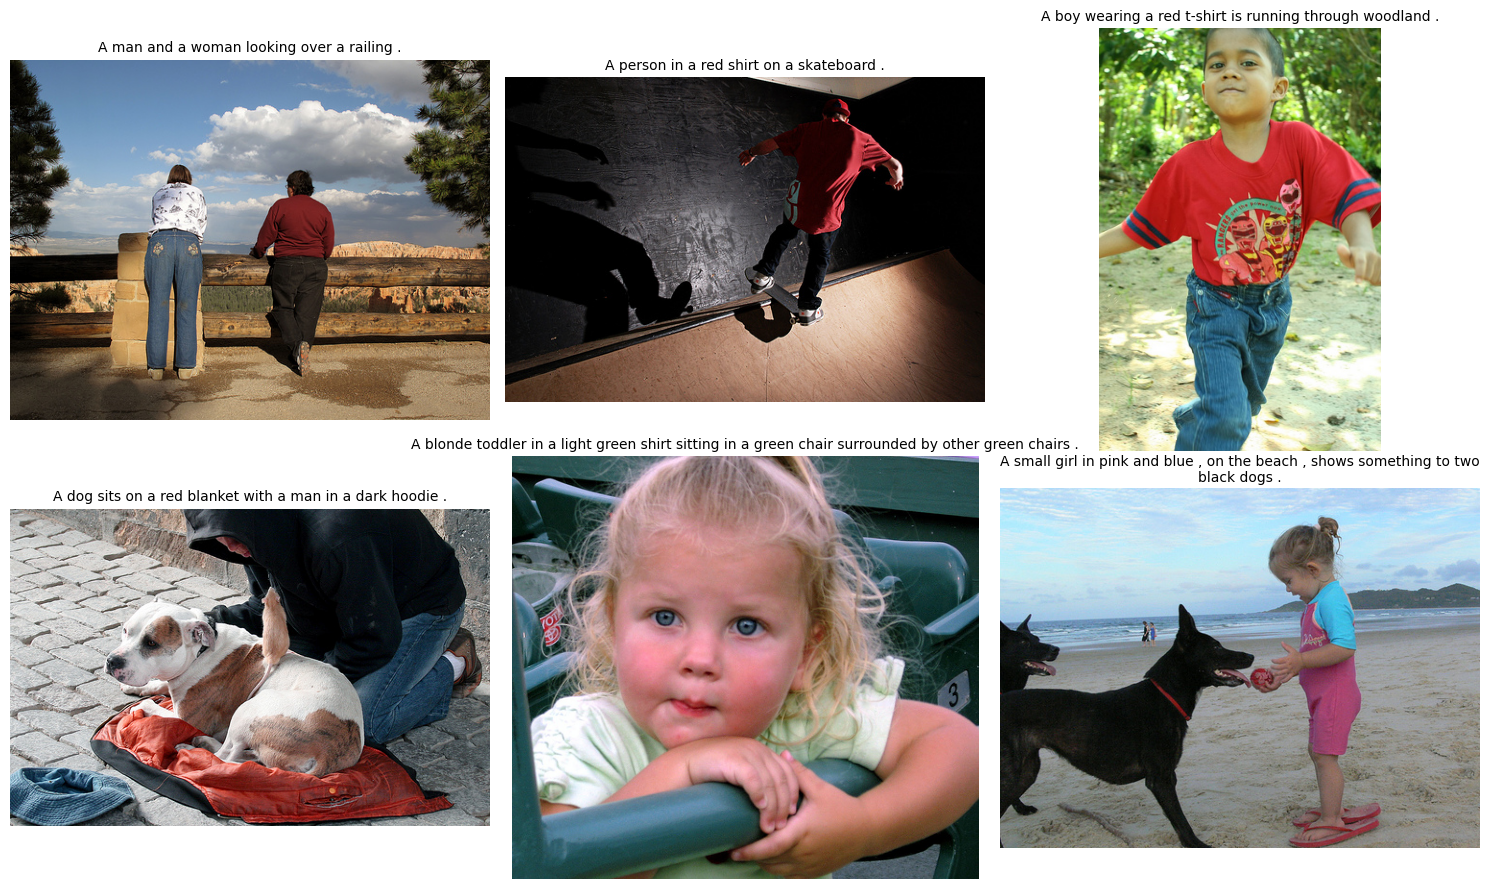

Five captions of the first image:
- A man and a woman looking over a railing .
- The two women are looking at mountains at a fence .
- Two people look at a view .
- Two people take in the view from behind a fence .
- Two women standing in front of a fence looking at mountains .


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, ax in enumerate(axes.flat):
    row = data["train"][i]
    ax.imshow(row["image"])
    ax.set_title(get_references(row)[0], fontsize=10, wrap=True)
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULT_DIR / "dataset_examples.png", dpi=160, bbox_inches="tight")
plt.show()
print("Five captions of the first image:")
for cap in get_references(data["train"][0]):
    print("-", cap)


## 4. Model and data loading

BLIP uses a vision encoder to represent the image and a text decoder to generate the caption. Training uses teacher forcing. Padding positions in the target labels are set to `-100` and excluded from the loss.

Training captions cycle across epochs. Validation loss uses the first reference caption consistently; all five references are used for test metrics.


In [6]:
processor = BlipProcessor.from_pretrained(MODEL_ID, revision=MODEL_REVISION)


def load_base_model():
    model = BlipForConditionalGeneration.from_pretrained(
        MODEL_ID, revision=MODEL_REVISION
    )
    for p in model.vision_model.parameters():
        p.requires_grad = False
    return model.to(DEVICE)


model = load_base_model()
param_counts = dict(
    total=sum(p.numel() for p in model.parameters()),
    trainable=sum(p.numel() for p in model.parameters() if p.requires_grad),
)
(RESULT_DIR / "parameter_counts.json").write_text(json.dumps(param_counts, indent=2))
print("Parameters:", param_counts)


class CaptionDataset(Dataset):
    def __init__(self, hf_dataset, training=False):
        self.hf_dataset = hf_dataset
        self.training = training
        self.epoch = 0

    def __len__(self):
        return len(self.hf_dataset)

    def __getitem__(self, i):
        row = self.hf_dataset[i]
        # Cycle through references with a fixed offset for each image.
        cap_index = (i + self.epoch) % 5 if self.training else 0
        return row["image"].convert("RGB"), get_references(row)[cap_index]


def collate_caption(batch):
    images, captions = zip(*batch)
    enc = processor(
        images=list(images),
        text=list(captions),
        padding=True,
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt",
    )
    labels = enc["input_ids"].clone()
    labels[enc["attention_mask"] == 0] = -100
    enc["labels"] = labels
    return dict(enc)


train_set = CaptionDataset(data["train"], training=True)
val_set = CaptionDataset(data["validation"], training=False)


def make_train_loader(epoch):
    train_set.epoch = epoch
    gen = torch.Generator().manual_seed(SEED + epoch)
    return DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=gen,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        collate_fn=collate_caption,
    )


val_loader = DataLoader(
    val_set,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=collate_caption,
)


def to_device(batch):
    return {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}


def amp_context():
    return (
        torch.autocast(device_type="cuda", dtype=torch.float16)
        if MIXED_PRECISION
        else nullcontext()
    )


check_batch = collate_caption(
    [train_set[i] for i in range(min(BATCH_SIZE, len(train_set)))]
)
assert torch.all(check_batch["labels"][check_batch["attention_mask"] == 0] == -100)
assert int((check_batch["labels"][:, 1:] != -100).sum()) > 0
print({k: tuple(v.shape) for k, v in check_batch.items()})


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Parameters: {'total': 247414076, 'trainable': 161323580}
{'pixel_values': (4, 3, 384, 384), 'input_ids': (4, 12), 'attention_mask': (4, 12), 'labels': (4, 12)}


## 5. Training sanity check

A small training batch is used to check the forward pass, loss, decoder gradients, and GPU memory. The visual encoder should receive no gradients. The original checkpoint is reloaded after this check, before the main experiment.


In [7]:
if RUN_SMOKE_TEST:
    model.train()
    model.vision_model.eval()
    smoke_optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], lr=LEARNING_RATE
    )
    smoke_scaler = torch.amp.GradScaler("cuda", enabled=MIXED_PRECISION)
    torch.cuda.reset_peak_memory_stats()
    b = to_device(check_batch)
    with amp_context():
        smoke_loss = model(**b).loss
    assert torch.isfinite(smoke_loss), "The training loss is not finite."
    smoke_scaler.scale(smoke_loss).backward()
    smoke_scaler.unscale_(smoke_optimizer)
    assert any(
        p.grad is not None and torch.isfinite(p.grad).all() and p.grad.abs().sum() > 0
        for p in model.text_decoder.parameters()
    ), "No finite, nonzero decoder gradient was found."
    assert all(p.grad is None for p in model.vision_model.parameters())
    smoke_scaler.step(smoke_optimizer)
    smoke_scaler.update()
    print("Smoke loss:", float(smoke_loss.detach()))
    print(
        "Peak allocated VRAM (GB):", round(torch.cuda.max_memory_allocated() / 2**30, 3)
    )
    del smoke_optimizer, smoke_scaler, smoke_loss, b, model
    gc.collect()
    torch.cuda.empty_cache()
    seed_everything(SEED)
    model = load_base_model()
else:
    print("Smoke test skipped by configuration.")


Smoke loss: 3.320065975189209
Peak allocated VRAM (GB): 3.366


## 6. Fine-tuning

The text decoder is optimized with AdamW and a cosine learning-rate schedule. Gradients are accumulated and normalized by the number of target tokens, including a partial final accumulation window. Mixed precision is used when enabled.

The checkpoint with the lowest token-weighted validation loss is retained for evaluation. Training state is saved at each epoch boundary, including optimizer, scheduler, and scaler state. Test scores are not used for checkpoint selection.


In [8]:
@torch.inference_mode()
def validation_loss(model, loader):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    for batch in tqdm(loader, desc="Validation loss", leave=False):
        batch = to_device(batch)
        ntokens = int((batch["labels"][:, 1:] != -100).sum())
        with amp_context():
            loss = model(**batch).loss
        assert torch.isfinite(loss), "The validation loss is not finite."
        total_loss += float(loss) * ntokens
        total_tokens += ntokens
    return total_loss / max(total_tokens, 1)


optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
steps_per_epoch = math.ceil(len(make_train_loader(0)) / GRAD_ACCUM_STEPS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.05 * steps_per_epoch * EPOCHS),
    num_training_steps=steps_per_epoch * EPOCHS,
)
scaler = torch.amp.GradScaler("cuda", enabled=MIXED_PRECISION)
start_epoch, best_val, history = 0, float("inf"), []

if LATEST_PATH.exists():
    # The saved state includes optimizer metadata; only load trusted checkpoints.
    state = torch.load(LATEST_PATH, map_location="cpu", weights_only=False)
    assert (
        state["signature"] == RUN_SIGNATURE
    ), "The checkpoint does not match this configuration."
    assert set(state["decoder"]) == set(model.text_decoder.state_dict())
    model.text_decoder.load_state_dict(state["decoder"])
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])
    start_epoch, best_val, history = (
        state["next_epoch"],
        state["best_val"],
        state["history"],
    )
    del state
    print(f"Resume at epoch {start_epoch + 1}; completed {start_epoch}/{EPOCHS}.")

for epoch in range(start_epoch, EPOCHS):
    seed_everything(SEED + epoch)
    loader = make_train_loader(epoch)
    model.train()
    model.vision_model.eval()
    optimizer.zero_grad(set_to_none=True)
    torch.cuda.reset_peak_memory_stats()
    t0 = time.perf_counter()
    weighted_loss, total_tokens = 0.0, 0
    pbar = tqdm(loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    window_tokens = 0
    loss_normalizer = BATCH_SIZE * MAX_TEXT_LENGTH * GRAD_ACCUM_STEPS
    for batch_index, batch in enumerate(pbar):
        batch = to_device(batch)
        ntokens = int((batch["labels"][:, 1:] != -100).sum())
        with amp_context():
            loss = model(**batch).loss
        if not torch.isfinite(loss):
            raise RuntimeError(
                "Non-finite training loss. Disable mixed precision in a new run."
            )
        # Accumulate summed token loss; normalize gradients once per accumulation window.
        scaler.scale(loss * ntokens / loss_normalizer).backward()
        window_tokens += ntokens
        weighted_loss += float(loss.detach()) * ntokens
        total_tokens += ntokens
        if (batch_index + 1) % GRAD_ACCUM_STEPS == 0 or batch_index + 1 == len(loader):
            scaler.unscale_(optimizer)
            for p in model.parameters():
                if p.grad is not None:
                    p.grad.mul_(loss_normalizer / max(window_tokens, 1))
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 1.0
            )
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            if (
                scaler.get_scale() >= old_scale
            ):  # Advance the scheduler only if the optimizer step was applied.
                scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            window_tokens = 0
        pbar.set_postfix(loss=round(weighted_loss / max(total_tokens, 1), 4))
    train_loss = weighted_loss / max(total_tokens, 1)
    val_loss = validation_loss(model, val_loader)
    elapsed = time.perf_counter() - t0
    history.append(
        dict(
            epoch=epoch + 1,
            train_loss=train_loss,
            val_loss=val_loss,
            epoch_seconds=elapsed,
            peak_allocated_vram_gb=torch.cuda.max_memory_allocated() / 2**30,
            learning_rate=optimizer.param_groups[0]["lr"],
        )
    )
    if val_loss < best_val:
        best_val = val_loss
        # Save locally first, then copy to Drive to reduce small-file I/O.
        staging = Path("/content/blip_best_staging")
        staging.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(staging, safe_serialization=True)
        processor.save_pretrained(staging)
        shutil.copytree(staging, BEST_DIR, dirs_exist_ok=True)
        (BEST_DIR / "selection.json").write_text(
            json.dumps(
                dict(
                    signature=RUN_SIGNATURE, epoch=epoch + 1, validation_loss=val_loss
                ),
                indent=2,
            )
        )
        print(f"Saved best model: epoch {epoch + 1}, val loss {val_loss:.4f}")
    resume_state = dict(
        signature=RUN_SIGNATURE,
        decoder={
            k: v.detach().cpu() for k, v in model.text_decoder.state_dict().items()
        },
        optimizer=optimizer.state_dict(),
        scheduler=scheduler.state_dict(),
        scaler=scaler.state_dict(),
        next_epoch=epoch + 1,
        best_val=best_val,
        history=history,
    )
    local_state = Path("/content/blip_latest_training_state.pt")
    torch.save(resume_state, local_state)
    temp_drive = LATEST_PATH.with_suffix(".tmp")
    shutil.copy2(local_state, temp_drive)
    os.replace(temp_drive, LATEST_PATH)
    del resume_state
    pd.DataFrame(history).to_csv(RESULT_DIR / "training_history.csv", index=False)
    print(
        f"Epoch {epoch + 1}: train={train_loss:.4f}, val={val_loss:.4f}, time={elapsed/60:.1f} min"
    )

assert (
    BEST_DIR / "selection.json"
).exists(), "No selected checkpoint was found. Complete the training stage first."
assert (
    json.loads((BEST_DIR / "selection.json").read_text())["signature"] == RUN_SIGNATURE
)
pd.DataFrame(history).to_csv(RESULT_DIR / "training_history.csv", index=False)
display(pd.DataFrame(history))
# Free optimizer + trained model before sequentially evaluating checkpoints.
del optimizer, scheduler, scaler, model
gc.collect()
torch.cuda.empty_cache()


Epoch 1/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/250 [00:00<?, ?it/s]

Saved best model: epoch 1, val loss 1.9368
Epoch 1: train=2.3283, val=1.9368, time=5.3 min


Epoch 2/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/250 [00:00<?, ?it/s]

...

Saved best model: epoch 4, val loss 1.8316
Epoch 4: train=1.8207, val=1.8316, time=6.3 min


Epoch 5/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation loss:   0%|          | 0/250 [00:00<?, ?it/s]

Saved best model: epoch 5, val loss 1.8244
Epoch 5: train=1.8042, val=1.8244, time=6.2 min


,epoch,train_loss,val_loss,epoch_seconds,peak_allocated_vram_gb,learning_rate
0,1,2.328261,1.936842,317.280623,3.461556,0.000019
1,2,1.897359,1.887745,326.250160,3.448764,0.000014
2,3,1.852093,1.850296,371.989198,3.448902,0.000008
3,4,1.820689,1.831613,378.194319,3.424648,0.000002
4,5,1.804166,1.824373,374.124315,3.434574,0.000000


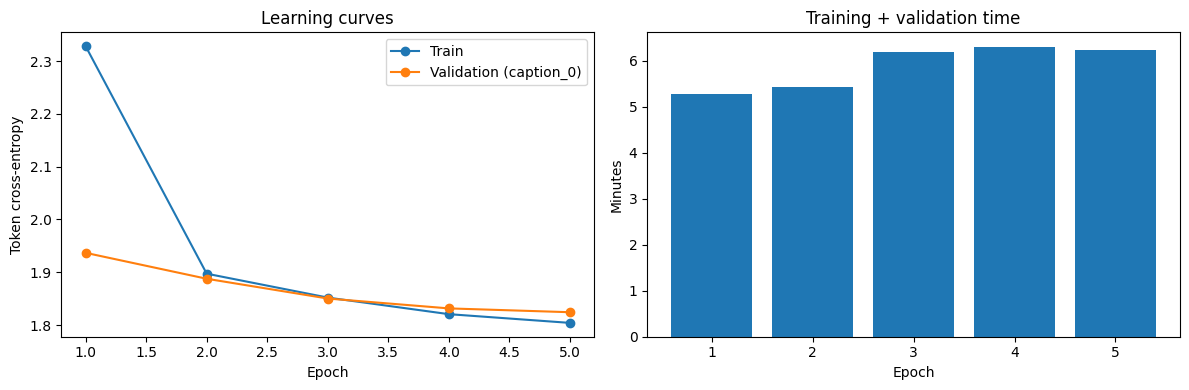

In [9]:
history_df = pd.read_csv(RESULT_DIR / "training_history.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df.epoch, history_df.train_loss, "o-", label="Train")
axes[0].plot(
    history_df.epoch, history_df.val_loss, "o-", label="Validation (caption_0)"
)
axes[0].set(xlabel="Epoch", ylabel="Token cross-entropy", title="Learning curves")
axes[0].legend()
axes[1].bar(history_df.epoch, history_df.epoch_seconds / 60)
axes[1].set(xlabel="Epoch", ylabel="Minutes", title="Training + validation time")
plt.tight_layout()
plt.savefig(RESULT_DIR / "training_curves.png", dpi=160, bbox_inches="tight")
plt.show()


## 7. Evaluation metrics

BLEU-1 through BLEU-4 are computed at corpus level with five references per image and no smoothing. CIDEr is computed using `pycocoevalcap.cider.Cider` on its native scale.

Both metrics use the same lowercase English word tokenizer. Punctuation is removed, while apostrophes inside words are retained. This preprocessing differs from COCO's PTB tokenizer, so scores should only be compared with experiments using the same evaluation settings. The reported CIDEr score is not CIDEr-D.


In [10]:
def tokenize_caption(text):
    return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", str(text).lower())


def compute_caption_metrics(predictions, references):
    assert len(predictions) == len(references) and len(predictions) > 1
    hyp_tokens = [tokenize_caption(p) for p in predictions]
    ref_tokens = [[tokenize_caption(r) for r in refs] for refs in references]
    assert all(len(refs) == 5 for refs in references)
    scores = {}
    for n in range(1, 5):
        scores[f"BLEU-{n}"] = float(
            corpus_bleu(ref_tokens, hyp_tokens, weights=tuple([1 / n] * n))
        )
    gts = {i: [" ".join(r) for r in refs] for i, refs in enumerate(ref_tokens)}
    res = {i: [" ".join(p)] for i, p in enumerate(hyp_tokens)}
    cider, per_image = Cider().compute_score(gts, res)
    scores["CIDEr"] = float(cider)
    return scores, np.asarray(per_image, dtype=float)


# Self-check: exact captions should score above unrelated ones on this synthetic corpus.
_test_refs = [
    [s] * 5
    for s in [
        "a small dog runs across the grass",
        "two people ride bicycles down a road",
        "a child holds a red balloon outside",
    ]
]
_good, _ = compute_caption_metrics([r[0] for r in _test_refs], _test_refs)
_bad, _ = compute_caption_metrics(["purple engines eat silver clocks"] * 3, _test_refs)
assert _good["BLEU-4"] > 0.99 and _good["CIDEr"] > _bad["CIDEr"]
print("Metric self-check passed.")


Metric self-check passed.


## 8. Test evaluation

The baseline is the original BLIP checkpoint, without additional fine-tuning in this experiment. Both checkpoints are evaluated on the same test images using identical beam-search settings. Reference captions are excluded from the generation input.

Generation time is measured after a warm-up batch and includes image processing, generation, and decoding. Model loading, dataset access, and metric computation are excluded. Seconds per image is a batch throughput measurement, rather than single-request latency.


In [11]:
@torch.inference_mode()
def generate_predictions(model, hf_dataset):
    model.eval()
    # Warm up with the same batch size, outside timing.
    warm_images = [
        hf_dataset[i]["image"].convert("RGB")
        for i in range(min(EVAL_BATCH_SIZE, len(hf_dataset)))
    ]
    warm = processor(images=warm_images, return_tensors="pt").to(DEVICE)
    with amp_context():
        model.generate(
            **warm, max_new_tokens=MAX_NEW_TOKENS, num_beams=NUM_BEAMS, do_sample=False
        )
    del warm
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    predictions, references, total_seconds = [], [], 0.0
    for start in tqdm(
        range(0, len(hf_dataset), EVAL_BATCH_SIZE), desc="Generate captions"
    ):
        rows = [
            hf_dataset[i]
            for i in range(start, min(start + EVAL_BATCH_SIZE, len(hf_dataset)))
        ]
        images = [row["image"].convert("RGB") for row in rows]
        references.extend([get_references(row) for row in rows])
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        inputs = processor(images=images, return_tensors="pt").to(DEVICE)
        with amp_context():
            generated = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=NUM_BEAMS,
                do_sample=False,
            )
        batch_predictions = processor.batch_decode(generated, skip_special_tokens=True)
        torch.cuda.synchronize()
        total_seconds += time.perf_counter() - t0
        predictions.extend([p.strip() for p in batch_predictions])
    timing = dict(
        generation_seconds=total_seconds,
        seconds_per_image=total_seconds / len(hf_dataset),
        peak_allocated_vram_gb=torch.cuda.max_memory_allocated() / 2**30,
    )
    return predictions, references, timing


all_outputs = {}
summary_rows = []
for name, checkpoint in [("baseline", MODEL_ID), ("fine_tuned", str(BEST_DIR))]:
    print("Evaluating:", name)
    eval_model = (
        load_base_model()
        if name == "baseline"
        else BlipForConditionalGeneration.from_pretrained(checkpoint).to(DEVICE)
    )
    predictions, references, timing = generate_predictions(eval_model, data["test"])
    scores, per_image = compute_caption_metrics(predictions, references)
    payload = dict(
        signature=RUN_SIGNATURE,
        model=name,
        source="test",
        n_images=len(predictions),
        quick_run=QUICK_RUN,
        scores=scores,
        timing=timing,
        predictions=predictions,
        references=references,
        cider_per_image=per_image.tolist(),
    )
    (RESULT_DIR / f"{name}_test.json").write_text(
        json.dumps(payload, indent=2, ensure_ascii=False)
    )
    all_outputs[name] = payload
    summary_rows.append(
        dict(model=name, n_test_images=len(predictions), **scores, **timing)
    )
    del eval_model
    gc.collect()
    torch.cuda.empty_cache()

summary = pd.DataFrame(summary_rows)
summary.to_csv(RESULT_DIR / "metrics_comparison.csv", index=False)
display(summary.round(4))
print("Selected checkpoint:", json.loads((BEST_DIR / "selection.json").read_text()))
print("Full test" if not QUICK_RUN else "Quick-run subset only")


Evaluating: baseline


Generate captions:   0%|          | 0/250 [00:00<?, ?it/s]

Evaluating: fine_tuned


Generate captions:   0%|          | 0/250 [00:00<?, ?it/s]

,model,n_test_images,BLEU-1,BLEU-2,BLEU-3,BLEU-4,CIDEr,generation_seconds,seconds_per_image,peak_allocated_vram_gb
0,baseline,1000,0.6586,0.5047,0.3736,0.2741,0.7066,150.4144,0.1504,1.7137
1,fine_tuned,1000,0.7454,0.5896,0.4529,0.3387,1.0064,150.9820,0.1510,1.7137


Selected checkpoint: {'signature': 'd70dff90e0283f12e32d7f841c833251047f9eef0256d9fa6fbffb313d885cdf', 'epoch': 5, 'validation_loss': 1.8243730219203504}
Full test


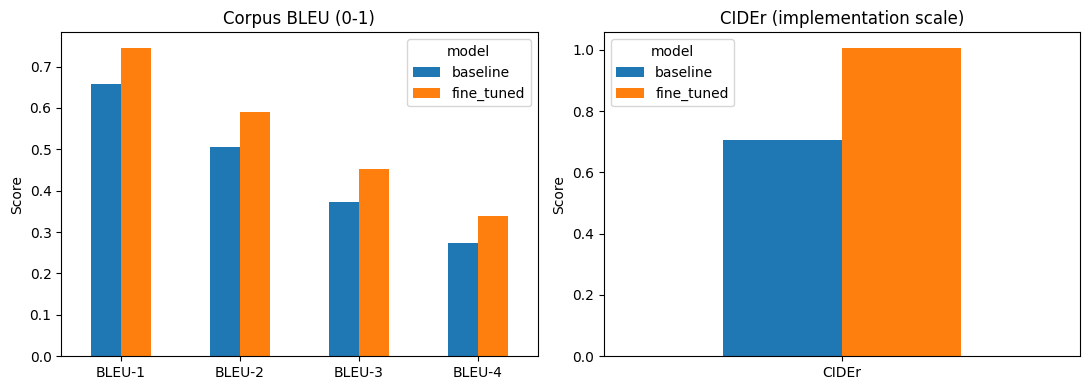

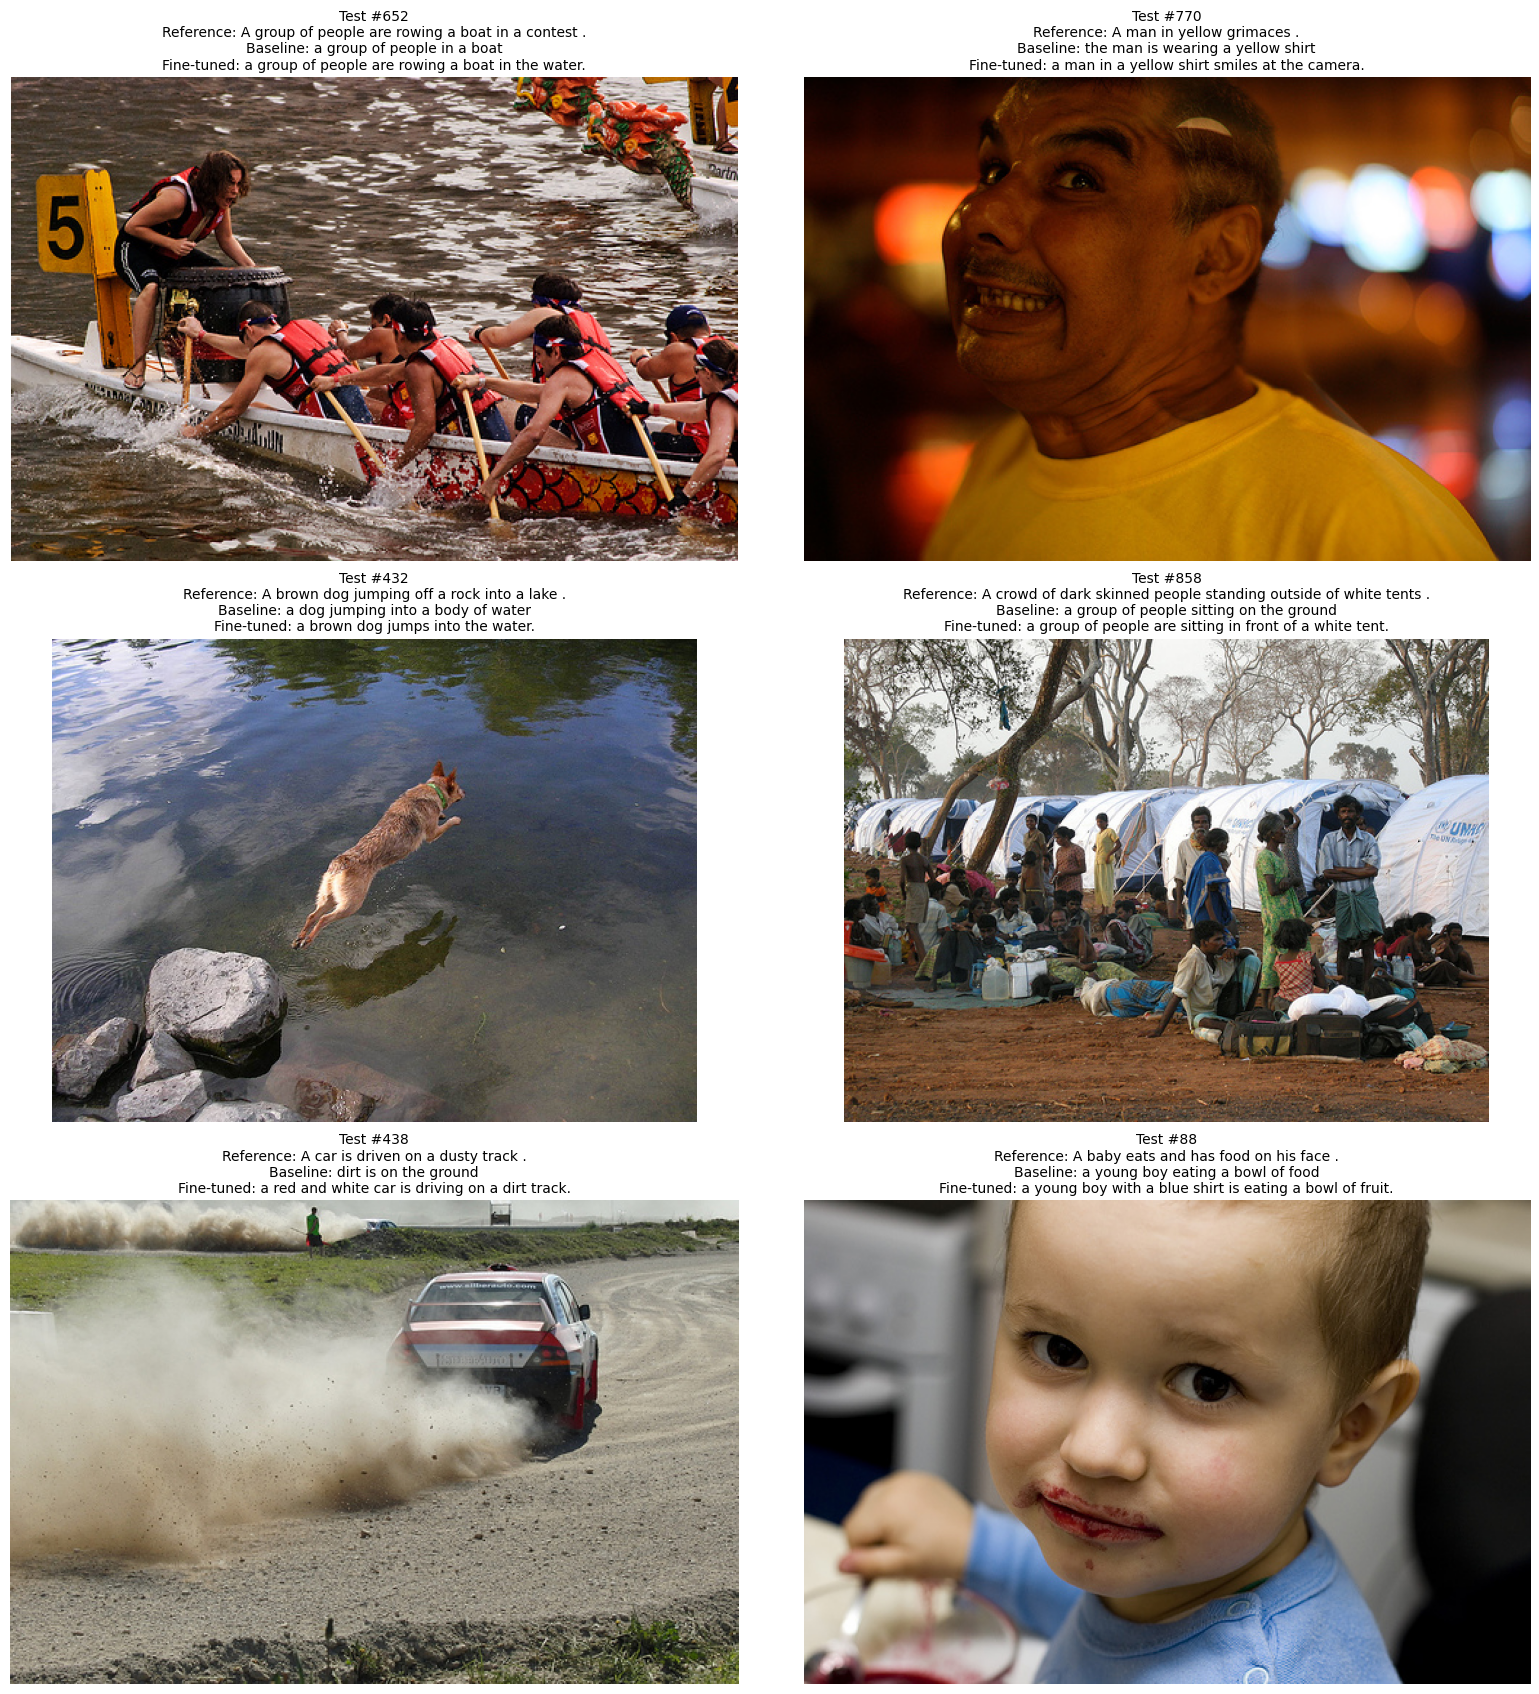

,test_index,baseline,fine_tuned,cider_delta
138,138,two men in white suits,a man in a white suit and a man in a white sui...,-2.571539
369,369,a dog in the snow,a tan dog is walking through the snow.,-2.465445
25,25,a man and a woman sitting on a bench,a shirtless man and a naked woman sit on a bench.,-2.192023
665,665,the woman is wearing a blue scarf around her head,a woman in a headscarf is standing in front of...,-2.121146
251,251,a man standing in front of a brick building,a man wearing a black hat and a black t - shir...,-1.900308


In [12]:
# Export one row per test image, including all five references.
rows = []
for i in range(len(data["test"])):
    row = dict(
        test_index=i,
        source_index=split_manifest["test"][i]["source_index"],
        pixel_sha256=split_manifest["test"][i]["pixel_sha256"],
        baseline=all_outputs["baseline"]["predictions"][i],
        fine_tuned=all_outputs["fine_tuned"]["predictions"][i],
        cider_baseline=all_outputs["baseline"]["cider_per_image"][i],
        cider_fine_tuned=all_outputs["fine_tuned"]["cider_per_image"][i],
    )
    row.update(
        {
            f"reference_{j}": ref
            for j, ref in enumerate(all_outputs["baseline"]["references"][i])
        }
    )
    rows.append(row)
comparison = pd.DataFrame(rows)
comparison["cider_delta"] = comparison.cider_fine_tuned - comparison.cider_baseline
comparison.to_csv(RESULT_DIR / "caption_comparison.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
summary.set_index("model")[["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]].T.plot.bar(
    ax=axes[0]
)
axes[0].set(title="Corpus BLEU (0-1)", ylabel="Score")
summary.set_index("model")[["CIDEr"]].T.plot.bar(ax=axes[1])
axes[1].set(title="CIDEr (implementation scale)", ylabel="Score")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(RESULT_DIR / "metrics_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

# Show a reproducible random sample of test images.
import textwrap

sample_ids = np.random.default_rng(SEED).choice(
    len(data["test"]), size=min(6, len(data["test"])), replace=False
)
fig, axes = plt.subplots(3, 2, figsize=(16, 17))
for ax, i in zip(axes.flat, sample_ids):
    row = comparison.iloc[int(i)]
    ax.imshow(data["test"][int(i)]["image"])
    text = f"Test #{i}\nReference: {row.reference_0}\nBaseline: {row.baseline}\nFine-tuned: {row.fine_tuned}"
    ax.set_title(
        "\n".join(textwrap.fill(line, 75) for line in text.split("\n")), fontsize=10
    )
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULT_DIR / "random_caption_examples.png", dpi=160, bbox_inches="tight")
plt.show()
display(
    comparison.sort_values("cider_delta").head(5)[
        ["test_index", "baseline", "fine_tuned", "cider_delta"]
    ]
)


## 9. Qualitative evaluation

Random test examples are shown alongside their reference and generated captions. The comparison CSV also includes per-image CIDEr scores and their difference.

For manual review, 20 images are sampled and model names are hidden behind A/B labels. Score object correctness, action correctness, hallucination, and readability. Record A, B, or tie as the preferred caption. Leave fields blank until the corresponding image has been reviewed; use NA for an action that does not apply. The model key is stored separately.


In [13]:
review_dir = RESULT_DIR / "review_images"
review_dir.mkdir(exist_ok=True)
rng = np.random.default_rng(SEED + 1)
review_ids = rng.choice(len(comparison), size=min(20, len(comparison)), replace=False)
review_rows, answer_key = [], []
for i in review_ids:
    i = int(i)
    names = ["baseline", "fine_tuned"]
    if rng.random() < 0.5:
        names.reverse()
    filename = f"test_{i:04d}.jpg"
    data["test"][i]["image"].convert("RGB").save(review_dir / filename)
    row = dict(
        test_index=i,
        image_file=filename,
        caption_A=all_outputs[names[0]]["predictions"][i],
        caption_B=all_outputs[names[1]]["predictions"][i],
        preferred="",
        notes="",
    )
    for letter in ["A", "B"]:
        for key in ["object_correct", "action_correct", "hallucination", "readability"]:
            row[f"{letter}_{key}"] = ""
    review_rows.append(row)
    answer_key.append(dict(test_index=i, A=names[0], B=names[1]))
review_path = RESULT_DIR / "human_review_template.csv"
# Preserve an existing review sheet.
if not review_path.exists():
    pd.DataFrame(review_rows).to_csv(review_path, index=False)
(RESULT_DIR / "human_review_model_key.json").write_text(
    json.dumps(answer_key, indent=2)
)
print("Review template:", review_path)


Review template: /content/drive/MyDrive/ImageCaptioning_Project/flickr8k_blip_decoder_v1/results/human_review_template.csv


## 10. Inference on an uploaded image

Set `RUN_UPLOAD_DEMO=True` to upload an image and generate a caption with the selected checkpoint. Uploaded images have no reference captions, so automatic caption metrics are not computed for this demonstration.


Saving images (10).jpg to images (10).jpg


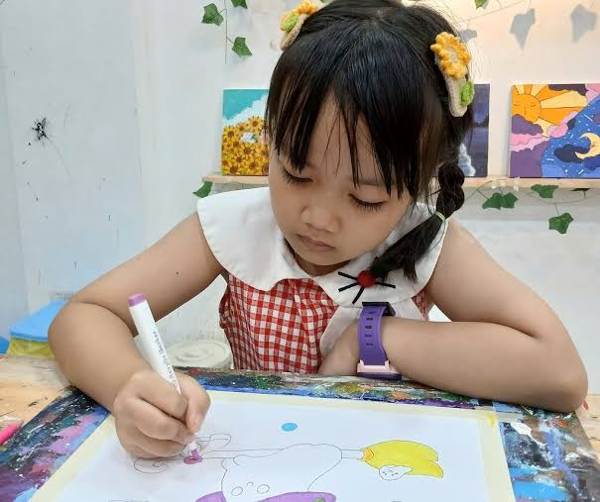

images (10).jpg : a young girl in a white shirt is drawing on a piece of paper.


In [16]:
RUN_UPLOAD_DEMO = True
if RUN_UPLOAD_DEMO:
    from google.colab import files
    import io

    uploaded = files.upload()
    demo_model = (
        BlipForConditionalGeneration.from_pretrained(BEST_DIR).to(DEVICE).eval()
    )
    with torch.inference_mode():
        for filename, content in uploaded.items():
            image = Image.open(io.BytesIO(content)).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(DEVICE)
            with amp_context():
                output = demo_model.generate(
                    **inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    num_beams=NUM_BEAMS,
                    do_sample=False
                )
            display(
                image.resize(
                    (
                        int(image.width * min(1, 600 / image.width)),
                        int(image.height * min(1, 600 / image.width)),
                    )
                )
            )
            print(filename, ":", processor.decode(output[0], skip_special_tokens=True))
    del demo_model
    gc.collect()
    torch.cuda.empty_cache()
else:
    print("Set RUN_UPLOAD_DEMO=True to caption an uploaded image.")


## 11. Export

The results archive includes metrics, predictions, figures, split records, and review images. Model weights and the training state remain in the run directory on Drive.

To resume after a disconnected session, run the notebook with the same configuration and run name. An incomplete epoch is repeated. If GPU memory is insufficient, reduce the batch sizes and use a new run name; increase gradient accumulation to retain the intended effective batch size.


In [15]:
report_note = f"""Image Captioning with BLIP on Flickr8k

Run: {RUN_NAME}
Quick run: {QUICK_RUN}

Dataset repository: {DATASET_ID}
Repository revision recorded at setup: {DATASET_REVISION}
Data loaded from converted Parquet files; source URLs are recorded in parquet_source.json.
The repository revision is metadata, not a pinned Parquet revision.
Model: {MODEL_ID}, commit {MODEL_REVISION}

Training: frozen visual encoder; train text decoder; one caption per image per epoch,
cyclic over 5 captions. Best checkpoint selected by validation loss on caption_0.
Test: 5 references/image, identical generation settings for both checkpoints.
BLEU: NLTK corpus_bleu, unsmoothed, lowercase regex word tokenizer.
CIDEr: pycocoevalcap.cider.Cider, same regex tokenizer; not CIDEr-D or official PTB scores.

Pretraining-data overlap has not been audited. Fine-tuning may improve or reduce caption quality.
seconds_per_image measures batch throughput, including processing/generation/decoding after warm-up.
Human-review fields are intentionally blank until someone inspects the images.
Best weights and epoch resume state are stored separately in the run folder.
"""
(RESULT_DIR / "README_results.txt").write_text(report_note)
archive_path = Path("/content") / f"{RUN_NAME}_results.zip"
with zipfile.ZipFile(archive_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(RESULT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(RUN_DIR)))
    z.write(config_path, arcname="config.json")
    z.write(BEST_DIR / "selection.json", arcname="best_checkpoint_selection.json")
shutil.copy2(archive_path, RUN_DIR / archive_path.name)
print("Results ZIP:", RUN_DIR / archive_path.name)
print("Best checkpoint:", BEST_DIR)
print("Resume state:", LATEST_PATH)
DOWNLOAD_RESULTS_ZIP = False
if DOWNLOAD_RESULTS_ZIP:
    from google.colab import files

    files.download(str(archive_path))


Results ZIP: /content/drive/MyDrive/ImageCaptioning_Project/flickr8k_blip_decoder_v1/flickr8k_blip_decoder_v1_results.zip
Best checkpoint: /content/drive/MyDrive/ImageCaptioning_Project/flickr8k_blip_decoder_v1/best_model
Resume state: /content/drive/MyDrive/ImageCaptioning_Project/flickr8k_blip_decoder_v1/latest_training_state.pt


## References

- Li, J., Li, D., Xiong, C., and Hoi, S. (2022). [BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation](https://arxiv.org/abs/2201.12086).
- [BLIP image-captioning checkpoint](https://huggingface.co/Salesforce/blip-image-captioning-base).
- [Flickr8k dataset distribution](https://huggingface.co/datasets/intro/flickr8k).
- [Transformers BLIP documentation](https://huggingface.co/docs/transformers/v4.51.3/model_doc/blip).
- [COCO caption evaluation implementation](https://github.com/salaniz/pycocoevalcap).
